# NeoFlux routines

In [34]:
import multineas as neas
import multineas.neoflux as neo
import numpy as np
import spiceypy as spy
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## NEOFLUX

We have to set instantiate the orbit object:

In [6]:
mu=1
orb=neo.KeplerianOrbit(mu)

### Orbit from elements

An elliptic orbit:

In [7]:
orb._scales

[1.3,
 1.0,
 3.141592653589793,
 6.283185307179586,
 6.283185307179586,
 6.283185307179586]

In [8]:
orb.setOrbit(0,celements=[1,0.6,0,0,0,0])

We can see in a glimpse all the properties of the orbit:

In [9]:
print(orb)

Keplerian orbit with mu = 1
        Elements:
            q = 1.0, a = 2.5, e = 0.6
            i = 0.0000000 rad = 0.00000 deg
            W = 0.0000000 rad = 0.00000 deg
            w = 0.0000000 rad = 0.00000 deg
            M = 0.0000000 rad = 0.00000 deg
            elements = [array([2.5, 0.6, 0. , 0. , 0. , 0. ])]
            celements = [array([1. , 0.6, 0. , 0. , 0. , 0. ])]
        Unconstrained elements (scales = [1.3  1.   3.14 6.28 6.28 6.28])
            Q = 1.2039728043259357, C = 0.4054651081081642, I = -inf, O = -inf, P = -inf, N = -inf
            uelements = [[np.float64(1.2039728043259357), np.float64(0.4054651081081642), np.float64(-inf), np.float64(-inf), np.float64(-inf), np.float64(-inf)]]
        State: 
            X = [array([ 1.  ,  0.  ,  0.  , -0.  ,  1.26,  0.  ])]
            r = [array([1., 0., 0.])]
            v = [array([-0.  ,  1.26,  0.  ])]
        Secondary:
            |a| = 2.5
            b = 2.0
            n = 0.25298221281347033
           

We can compute the future state of the orbit:

In [11]:
t=1
Md,dt,X=orb.propToTime(t)
print(f"M @ {t} = {Md} rad = {Md*neo.Angle.Rad}")
print(f"Delta t = {dt}")
print(f"X @ t = {[X]}")

M @ 1 = 0.25298221281347033 rad = 14.494813086092266
Delta t = 1
X @ t = [array([ 0.58620756,  1.1020673 ,  0.        , -0.6979715 ,  0.84560407,
        0.        ])]


And using this method we can for instance plot the orbit:

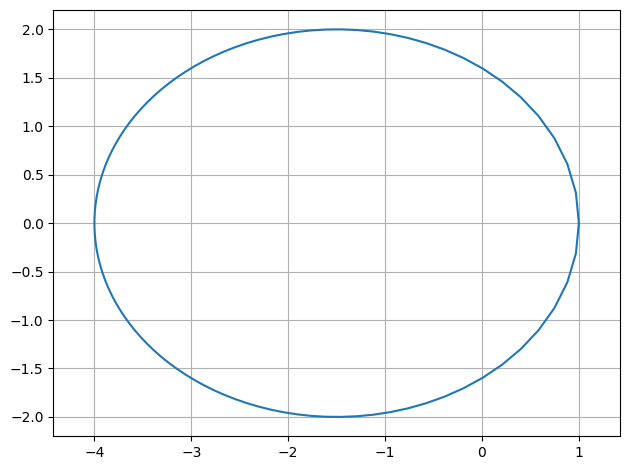

In [14]:
Nt=100
ts=np.linspace(0,orb.T,Nt)
Xs=np.zeros((Nt,6))
for i,t in enumerate(ts):
    Md,dt,Xs[i]=orb.propToTime(t)
    
plt.figure()
plt.plot(Xs[:,0],Xs[:,1])
plt.axis("equal")
plt.grid()
plt.tight_layout()

An hiperbolic orbit:

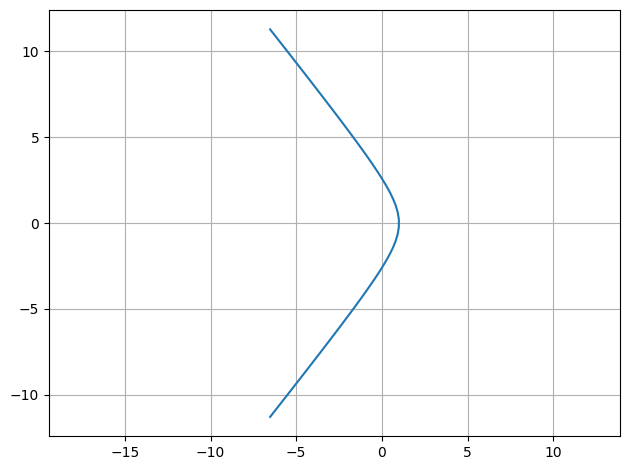

In [15]:
orb.setOrbit(0,celements=[1,1.6,0,0,0,0])
Nt=100
ts=np.linspace(-orb.T,orb.T,Nt)
Xs=np.zeros((Nt,6))
for i,t in enumerate(ts):
    Md,dt,Xs[i]=orb.propToTime(t)
    
plt.figure()
plt.plot(Xs[:,0],Xs[:,1])
plt.axis("equal")
plt.grid()
plt.tight_layout()

There's a plotting method:

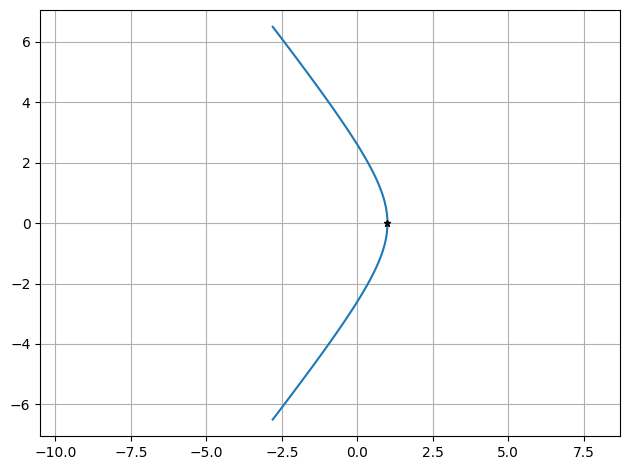

In [16]:
fig=plt.figure()
ax=fig.gca()
orb.plotOrbit(ax)
ax.grid()
fig.tight_layout()

And you can personalize the properties:

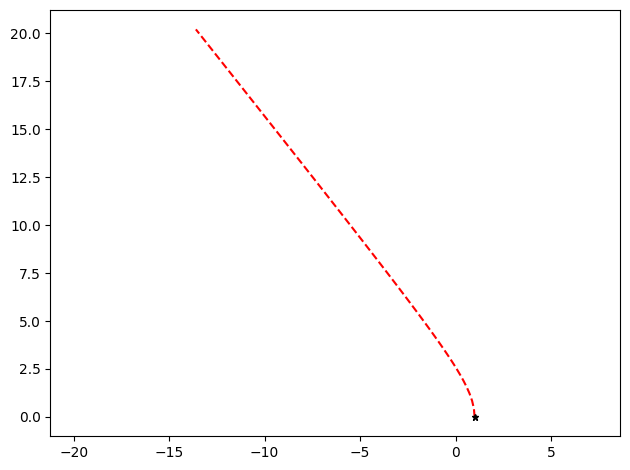

In [17]:
fig=plt.figure()
ax=fig.gca()
orb.plotOrbit(ax,fi=0,fe=2,lineargs=dict(ls='--',color='r'))
fig.tight_layout()

You may also plot in 3-D:

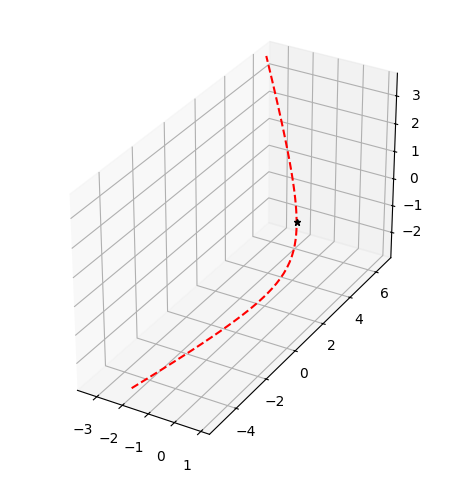

In [20]:
orb.setOrbit(0,celements=[1,1.6,30*neo.Angle.Deg,0,0,30*neo.Angle.Deg])
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
orb.plotOrbit(ax,lineargs=dict(ls='--',color='r'))
fig.tight_layout()

One of the most interesting methods is the `propToDistance` that allows to compute the state of a particle given the distance to the center.  This is good to know the orbital elements of the particle when emerging from the Sphere of Influence (SoI) of a body.

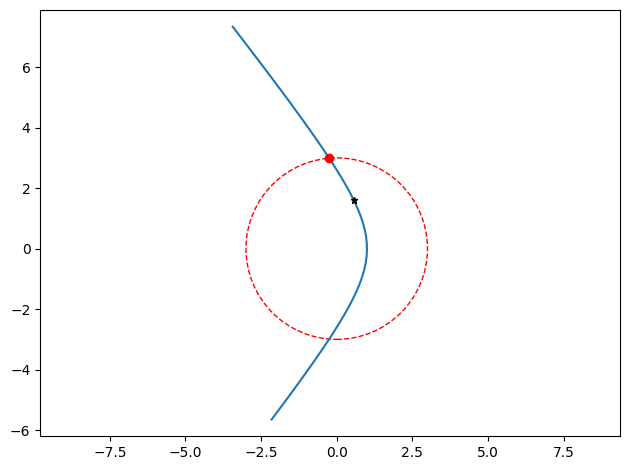

In [21]:
orb.setOrbit(0,celements=[1,1.6,0,0,0,30*neo.Angle.Deg])
D=3
Md,dt,X=orb.propToDistance(D,direction=1)

fig=plt.figure()
ax=fig.gca()
orb.plotOrbit(ax)
ax.plot(X[0],X[1],'ro')
import matplotlib.patches as pt
ax.add_patch(pt.Circle((0,0),D,color='r',fill=False,ls='dashed'))
fig.tight_layout()

## Sampling

In [22]:
s=neo.Sample(1000)

Once the sample is generated we can generate points on a sphere:

In [23]:
s.genUnitSphere()

The coordinates of the points in polar (`pp`) and in cartesians (`ss`) are stored in this matrices:

In [24]:
s.pp,s.ss

(array([[ 1.        ,  1.46597107, -1.52607124],
        [ 1.        ,  3.8659343 , -1.49331728],
        [ 1.        ,  6.26589753, -1.47075461],
        ...,
        [ 1.        ,  0.54926669,  1.47075461],
        [ 1.        ,  2.94922992,  1.49331728],
        [ 1.        ,  5.34919315,  1.52607124]], shape=(1000, 3)),
 array([[ 0.00467818,  0.04446476, -0.999     ],
        [-0.05796879, -0.05128956, -0.997     ],
        [ 0.09986   , -0.00172653, -0.995     ],
        ...,
        [ 0.08518408,  0.05214089,  0.995     ],
        [-0.0759739 ,  0.01479752,  0.997     ],
        [ 0.02658597, -0.03594699,  0.999     ]], shape=(1000, 3)))

In [25]:
s._calcDistances()
s.dmin,s.dmed,s.dmax

(np.float64(0.03858624904864977),
 np.float64(0.10632277490669279),
 np.float64(0.11128918576261708))

The method creates point that can be too close.  For this purpose is better to purge the points in such a way that points not closer that a given criterium is met:

In [26]:
s.purgeSample(tol=0.9)
s.dmin,s.dmed,s.dmed

(np.float64(0.09777409588068323),
 np.float64(0.1063660423834176),
 np.float64(0.1063660423834176))

Notice that now the closest point is close to the average.

Finally we can show the result:

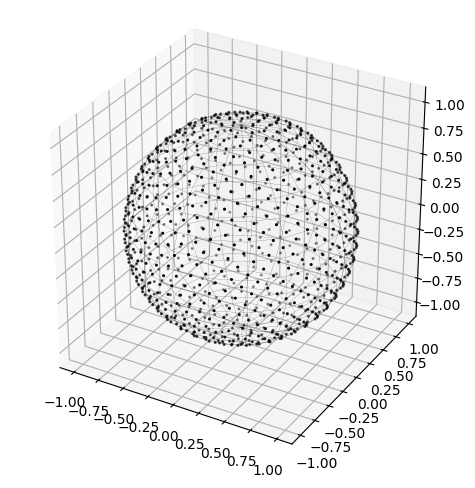

In [29]:
s.plotSample()
s.fig.savefig("gallery/points-sphere.png")

You may also generate points on a circle:

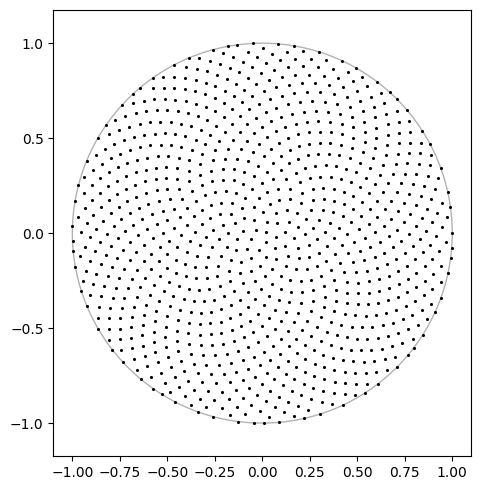

In [32]:
s.genUnitCircle()
s.plotSample()
s.fig.savefig("gallery/points-disk.png")

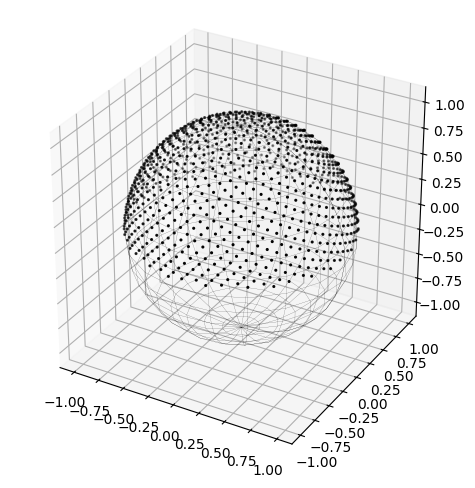

In [33]:
s.genUnitHemisphere()
s.plotSample()
s.fig.savefig("gallery/points-hemisphere.png")